In [1]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [3]:
df = pd.read_csv('../data/raw/products.csv')

In [4]:
x = df['product']
y = df['category']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
model_name = 'xlm-roberta-base'

In [6]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
labels = sorted(df['category'].unique())

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

y_train_encoded = y_train.map(label2id)
y_test_encoded = y_test.map(label2id)

In [8]:
train_encodings = tokenizer(
    x_train.tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    x_test.tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

In [9]:
for text in x_test.head(5):
    print(text)
    print(tokenizer.tokenize(text))
    print()

便携式投影仪
['▁', '便', '携', '式', '投影', '仪']

map tulang ukuran A4
['▁map', '▁tulang', '▁ukuran', '▁A', '4']

lampu sorot tanam untuk koridor
['▁lampu', '▁so', 'rot', '▁tan', 'am', '▁untuk', '▁koridor']

buku agenda ukran A5
['▁buku', '▁agenda', '▁ukr', 'an', '▁A', '5']

baut kecil segi enam
['▁baut', '▁kecil', '▁segi', '▁enam']



In [21]:
class ProductDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [29]:
train_dataset = ProductDataset(
    train_encodings,
    y_train_encoded.reset_index(drop=True)
)

test_dataset = ProductDataset(
    test_encodings,
    y_test_encoded.reset_index(drop=True)
)

In [30]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(labels), 
    label2id=label2id, 
    id2label=id2label,
    low_cpu_mem_usage=True
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
from transformers import TrainingArguments, Trainer

In [32]:
training_args = TrainingArguments(
    output_dir='./xlmr_results',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to='none'
)

In [33]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [34]:
trainer.train()

c:\Users\Annisa Tazkiya\Documents\chinese-indonesian-product-classification\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=100, training_loss=1.5737966918945312, metrics={'train_runtime': 473.606, 'train_samples_per_second': 1.689, 'train_steps_per_second': 0.211, 'total_flos': 9044686147200.0, 'train_loss': 1.5737966918945312, 'epoch': 5.0})

In [35]:
predictions = trainer.predict(test_dataset)

y_pred_xlmr = np.argmax(
    predictions.predictions,
    axis=1
)

c:\Users\Annisa Tazkiya\Documents\chinese-indonesian-product-classification\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [36]:
xlmr_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_xlmr
)

xlmr_f1 = f1_score(
    y_test_encoded,
    y_pred_xlmr,
    average='macro'
)

print('XLM-R Accuracy:', round(xlmr_accuracy, 3))
print('XLM-R Macro-F1:', round(xlmr_f1, 3))

XLM-R Accuracy: 0.525
XLM-R Macro-F1: 0.427


In [38]:
xlmr_cm = confusion_matrix(
    y_test_encoded,
    y_pred_xlmr
)

xlmr_cm

array([[0, 2, 0, 4, 2],
       [0, 8, 0, 0, 0],
       [0, 1, 1, 0, 6],
       [0, 0, 0, 4, 4],
       [0, 0, 0, 0, 8]])

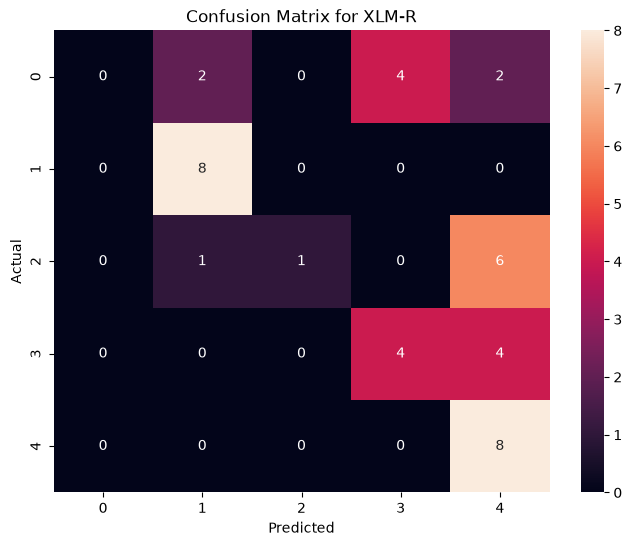

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    xlmr_cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XLM-R')

plt.show()